## Import the necessary functions 

In [1]:
# To load .nc files 
import xarray as xr

# For base functions
import numpy as np

# To transform coordinates from lat lon to x y 
from pyproj import Transformer

# Personalised functions created for this NN application
from NEMO_NN_functions import *

# To see progress on steps which take ages 
from tqdm import tqdm

# To plot figures 
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# To extract just the bedmachine mask within the NEMO 1 degree grid 
from shapely.geometry import Polygon
#from shapely.vectorized import contains ## Will become depreciated 
from shapely import contains_xy         ## Use this instead...

## Set variables 

In [2]:
# Load in the recalculated basins from Clara's mask 
basins_remapped = np.loadtxt('remapped.txt', delimiter = ',')

In [33]:
# Load in the bounds of the cells
# Load in the boundaries of the cells
filepath_bounds = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/grid_eORCA025_bounds.nc'
bounds25 = xr.open_dataset(filepath_bounds)

# Filepath_bedmachine 
version_bmach = 'BMach2'
if version_bmach == 'BMach3':
    filepath_bedmachine = '../AIAI_data/BedMachineAntarctica-v3.nc'
    bmach3 = xr.open_dataset(filepath_bedmachine)
    xbmach,ybmach = np.meshgrid(bmach3.x, bmach3.y)
elif version_bmach == 'BMach2':
    filepath_bedmachine = '../AIAI_data/BedmachineAntarctica-2020-07-15.nc'
    bmach3 = xr.open_dataset(filepath_bedmachine)
    xbmach,ybmach = np.meshgrid(bmach3.x, bmach3.y)
elif version_bmach == 'BMach4':
    filepath_bedmachine = '../AIAI_data/BedMachineAntarctica-v4.0.nc'
    bmach3 = xr.open_dataset(filepath_bedmachine)
    xbmach,ybmach = np.meshgrid(bmach3.x, bmach3.y)
else:
    print('I do not recognise this version of Bedmachine')
    bmach3.close()
    xbmach = []; ybmach = []

calculate_normally = True
#calculate_normally = 'threshold'
if calculate_normally == True:
    threshold_pc = 9999
elif calculate_normally == 'threshold':
    threshold_pc = 60
else:
    print('I do not recognise this way of calculating the mask')

filepath_new_mask = '/bettik/ockendeh/NEMO_simulations/test_mask_geoms/geometric_masks_NEMO025_' \
                                                        + version_bmach + '_' + str(threshold_pc) + 'pc.nc'
filepath_geomvars_new = '/bettik/ockendeh/NEMO_simulations/test_mask_geoms/geom_vars_NEMO025_' \
                                                        + version_bmach + '_' + str(threshold_pc) + 'pc.nc'
print(filepath_new_mask)
print(filepath_geomvars_new)

/bettik/ockendeh/NEMO_simulations/test_mask_geoms/geometric_masks_NEMO025_BMach2_60pc.nc
/bettik/ockendeh/NEMO_simulations/test_mask_geoms/geom_vars_NEMO025_BMach2_60pc.nc


## For the NEMO 1/4 degree grid, we want to include cells which contain ice shelf, and which are not in the NEMO 1 degree grid 

### **Calculate which points contain ice shelf**

In [34]:
# For the NEMO 1/4 degree grid, extract the bedmachine points in the cell
# calculate the fraction of each land type within the cell 

# Cell coordinates 
#lat = masks.lat  # (lat)
#lon = masks.lon  # (lon)
# Boundaries of the cells 
# It would be better to do this with the actual NEMO grid corners but don't have those with this mask
#lon_right = lon + 0.125
#lat_left = lon - 0.125
#lat_top = lat + 0.025
#lat_bottom = lat - 0.025
# Calculate the fraction of each land type within the cell 
do_calculation = False
if do_calculation == True:
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    fraction_OO = np.ones(bounds25.lat.shape) * np.nan
    fraction_IC = np.ones(bounds25.lat.shape) * np.nan
    fraction_GI = np.ones(bounds25.lat.shape) * np.nan
    fraction_IFL = np.ones(bounds25.lat.shape) * np.nan
    fraction_LV = np.ones(bounds25.lat.shape) * np.nan
    for i in range(masks.lat.shape[0]):
        for j in range(masks.lon.shape[1]):
            x_square = []
            y_square = []
            for jkl in (0,1,2,3):
                x2, y2 = transformer.transform(bounds25.lat_bnds.sel(nv4 = jkl)[i,j].values, \
                                                bounds25.lon_bnds.sel(nv4 = jkl)[i,j].values)
                x_square.append(x2)
                y_square.append(y2)
            bounds = [np.min(x_square), np.max(x_square), np.min(y_square), np.max(y_square)]
            # Extract the bedmachine mask within the boundaries of the cell 
            bmach_slice = bmach3.sel(x=slice(bounds[0], bounds[1]), y=slice(bounds[3], bounds[2]))
            if len(bmach_slice.x) == 0:
                    a = np.nan
            else:
                # List corners of rotated rectangle and create polygon
                corners = [(x_square[0], y_square[0]), (x_square[1], y_square[1]), \
                           (x_square[2], y_square[2]), (x_square[3], y_square[3])]
                poly = Polygon(corners)
                # Mask of points inside polygon
                X, Y = np.meshgrid(bmach_slice.x.values, bmach_slice.y.values)
                mask = contains_xy(poly, X, Y)
                # Extract bmach_slice inside polygon
                sub_mask = bmach_slice.mask.where(mask == True)
                # Calculate the fraction of points in the mask which are not 100% ocean/cavity
                total_points = np.sum(~np.isnan(sub_mask))
                if total_points > 0:
                    fraction_GI[i,j] = np.sum(sub_mask == 2).values/total_points
                    fraction_IFL[i,j] = np.sum(sub_mask == 1).values/total_points
                    fraction_LV[i,j] = np.sum(sub_mask == 4).values/total_points
                    fraction_OO[i,j] = np.sum(sub_mask == 0).values/total_points
                    fraction_IC[i,j] = np.sum(sub_mask == 3).values/total_points 
            print(i+1, j+1, 'out of', bounds25.lat.shape[0], '     ', end = '\r')
    if filepath_bedmachine == '../AIAI_data/BedmachineAntarctica-2020-07-15.nc':
        np.savetxt('fraction_IC_025f_b2.csv', fraction_IC)
        np.savetxt('fraction_OO_025f_b2.csv', fraction_OO)
        np.savetxt('fraction_GI_025f_b2.csv', fraction_GI)
        np.savetxt('fraction_IFL_025f_b2.csv', fraction_IFL)
        np.savetxt('fraction_LV_025f_b2.csv', fraction_LV)
    elif filepath_bedmachine == '../AIAI_data/BedMachineAntarctica-v3.nc':
        np.savetxt('fraction_IC_025f.csv', fraction_IC)
        np.savetxt('fraction_OO_025f.csv', fraction_OO)
        np.savetxt('fraction_GI_025f.csv', fraction_GI)
        np.savetxt('fraction_IFL_025f.csv', fraction_IFL)
        np.savetxt('fraction_LV_025f.csv', fraction_LV)
    elif filepath_bedmachine == '../AIAI_data/BedMachineAntarctica-v4.0.nc':
        np.savetxt('fraction_IC_025f_b4.csv', fraction_IC)
        np.savetxt('fraction_OO_025f_b4.csv', fraction_OO)
        np.savetxt('fraction_GI_025f_b4.csv', fraction_GI)
        np.savetxt('fraction_IFL_025f_b4.csv', fraction_IFL)
        np.savetxt('fraction_LV_025f_b4.csv', fraction_LV)
    else:
        print('You have not provided filepaths for the output from this version of Bedmachine?')
else:
    # Load from file 
    print('Loading from file, processed from:', filepath_bedmachine)
    if filepath_bedmachine == '../AIAI_data/BedmachineAntarctica-2020-07-15.nc':
        fraction_IC  = np.loadtxt('fraction_IC_025f_b2.csv')
        fraction_OO  = np.loadtxt('fraction_OO_025f_b2.csv')
        fraction_GI  = np.loadtxt('fraction_GI_025f_b2.csv')
        fraction_IFL = np.loadtxt('fraction_IFL_025f_b2.csv')
        fraction_LV  = np.loadtxt('fraction_LV_025f_b2.csv')
    elif filepath_bedmachine == '../AIAI_data/BedMachineAntarctica-v3.nc':
        fraction_IC  = np.loadtxt('fraction_IC_025f.csv')
        fraction_OO  = np.loadtxt('fraction_OO_025f.csv')
        fraction_GI  = np.loadtxt('fraction_GI_025f.csv')
        fraction_IFL = np.loadtxt('fraction_IFL_025f.csv')
        fraction_LV  = np.loadtxt('fraction_LV_025f.csv')
    elif filepath_bedmachine == '../AIAI_data/BedMachineAntarctica-v4.0.nc':
        fraction_IC  = np.loadtxt('fraction_IC_025f_b4.csv')
        fraction_OO  = np.loadtxt('fraction_OO_025f_b4.csv')
        fraction_GI  = np.loadtxt('fraction_GI_025f_b4.csv')
        fraction_IFL = np.loadtxt('fraction_IFL_025f_b4.csv')
        fraction_LV  = np.loadtxt('fraction_LV_025f_b4.csv')
    else:
        print('You have not provided a bedmachine file which has already been processed')

Loading from file, processed from: ../AIAI_data/BedmachineAntarctica-2020-07-15.nc


### **Calculate which points are included in the NEMO 1 degree grid**

Ideally we would do this properly with NEMO 1 degree grid, but because it is difficult to add points to the domain CFG, we are actually going to do this with the domain CFG instead. You can see how this would have been done with the NEMO 1 grid in the other notebook...

In [35]:
# Load in the domain CFG
filepath_domain_CFG_1 = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.4.3_CavsForNN_domain_cfg.nc'
CFG = xr.open_dataset(filepath_domain_CFG_1)

In [36]:
# Extract cells which are ocean in the domain CFG
CFG_ocean = (CFG.bottom_level.isel(t=0)>0).values

In [37]:
# Work out which NEMO 025 cells are in this region

# Prepare NEMO 1 grid 
transformer = Transformer.from_crs("epsg:4326", "epsg:3031", always_xy=True)
x_coords, y_coords = transformer.transform(CFG.nav_lon.values, CFG.nav_lat.values)

# Create KDTree for NEMO 1 ocean mask
src_points = np.column_stack([x_coords.ravel(),y_coords.ravel()])
tree = cKDTree(src_points)

# Prepare NEMO 025 grid points 
x_mask, y_mask = transformer.transform(bounds25.lon.values, bounds25.lat.values)

# Create a function to make mask of nearest NEMO 1 values
def nearest(x_mask, y_mask, x_shift = 0, y_shift = 0):
    tgt_points = np.column_stack([x_mask.ravel() + x_shift,
                                  y_mask.ravel() + y_shift])
    # Query nearest neighbours
    dist, idx = tree.query(tgt_points)
    # Extract mask values at nearest neighbour locations
    nearest_values = CFG_ocean.ravel()[idx]
    # Reshape back to target grid shape
    nearest_values = nearest_values.reshape(bounds25.lat.values.shape)
    nearest_values = nearest_values.astype(int)
    return nearest_values

# Apply to the cell centres but with a shift each time to ensure that edges and corners are included
nv1 = nearest(x_mask, y_mask, 1000, 0)
nv2 = nearest(x_mask, y_mask, -1000, 0)
nv3 = nearest(x_mask, y_mask, 0, 1000)
nv4 = nearest(x_mask, y_mask, 0, -1000)
# Calculate a mask of the points which can be included 
nearest_total = (np.isnan(nv1)) & (np.isnan(nv2)) & (np.isnan(nv3)) & (np.isnan(nv4))
nearest_total = (nv1 != 1) | (nv2 != 1) | (nv3 != 1) | (nv4 != 1)

# Calculate a mask of the fraction of each cell to include... 
# Although might use a bedmachine mask later?
#nv1[np.isnan(nv1)] = 0
#nv2[np.isnan(nv2)] = 0
#nv3[np.isnan(nv3)] = 0
#nv4[np.isnan(nv4)] = 0
fraction_cell_include = (4 - (nv1+nv2+nv3+nv4))/4
# But then we actually only want to include regions where there is ice shelf 
fraction = fraction_cell_include*fraction_IC#*nearest_total
fraction[fraction == 0] = np.nan

In [49]:
plot_figure = True
if plot_figure == True:
    # Calculate some things for plotting a figure...
    grounded_ice = (fraction_GI + fraction_IFL + fraction_LV)
    
    fully_grounded = grounded_ice==1
    fully_grounded = fully_grounded.astype('float32')
    fully_grounded[fully_grounded == 0] = np.nan
    
    fully_ocean = fraction_OO == 1
    fully_ocean = fully_ocean.astype('float32')
    fully_ocean[fully_ocean == 0] = np.nan
    
    #fully_GIOO = grounded_ice + fraction_OO
    fully_GIOO = ((grounded_ice + fraction_OO) == 1) & (fraction_OO <1) & (grounded_ice <1)
    fully_GIOO = fully_GIOO.astype('float32')
    fully_GIOO[fully_GIOO == 0] = np.nan
    
    fully_ice = fraction_IC == 1
    fully_ice = fully_ice.astype('float32')
    fully_ice[fully_ice == 0] = np.nan
    
    fully_ICOO = ((fraction_IC + fraction_OO) == 1) & (fraction_OO <1) & (fraction_IC <1)
    fully_ICOO = fully_ICOO.astype('float32')
    fully_ICOO[fully_ICOO == 0] = np.nan
    
    fully_GIIC = ((grounded_ice + fraction_IC) == 1) & (fraction_IC <1) & (grounded_ice <1)
    fully_GIIC = fully_GIIC.astype('float32')
    fully_GIIC[fully_GIIC == 0] = np.nan
    
    mix = (((grounded_ice + fraction_IC + fraction_OO) == 1) \
           & (fraction_IC <1) & (grounded_ice <1) & (fraction_OO <1)\
          & ((grounded_ice + fraction_IC) < 1) & ((fraction_OO + fraction_IC) < 1) & ((grounded_ice + fraction_OO) < 1))
    mix = mix.astype('float32')
    mix[mix == 0] = np.nan
    
    # And for the NEMO eORCA1 grid 
    NEMO_O = fraction_cell_include == 0
    NEMO_O = NEMO_O.astype('float32')
    NEMO_O[NEMO_O == 0] = np.nan
    
    NEMO_G = fraction_cell_include == 1
    NEMO_G = NEMO_G.astype('float32')
    NEMO_G[NEMO_G == 0] = np.nan
    
    NEMO_E = (fraction_cell_include > 0) & (fraction_cell_include <1)
    NEMO_E = NEMO_E.astype('float32')
    NEMO_E[NEMO_E == 0] = np.nan
else:
    print('No need to calculate if you aren\'t plotting the figure')

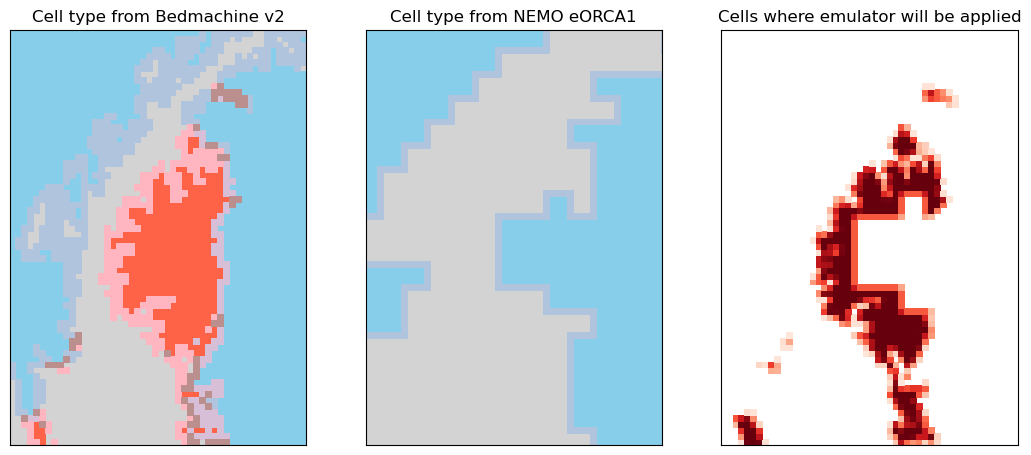

In [53]:
if plot_figure == True:
    fig, ax = plt.subplots(1,3, figsize = (13,8))
    ax[0].pcolor(fully_grounded, cmap = mcolors.ListedColormap(['lightgrey']))
    ax[0].pcolor(fully_ocean, cmap = mcolors.ListedColormap(['skyblue']))
    ax[0].pcolor(fully_GIOO, cmap = mcolors.ListedColormap(['lightsteelblue']))
    ax[0].pcolor(fully_ice, cmap = mcolors.ListedColormap(['tomato']))
    ax[0].pcolor(fully_ICOO, cmap = mcolors.ListedColormap(['thistle']))
    ax[0].pcolor(fully_GIIC, cmap = mcolors.ListedColormap(['lightpink']))
    ax[0].pcolor(mix, cmap = mcolors.ListedColormap(['rosybrown']))
    ax[0].pcolor(grounded_ice >= 0, cmap = mcolors.ListedColormap(['lightgrey']), zorder = 0)
    #ax[0].pcolor(IC_nans, cmap = 'Reds', vmin = -0.1, vmax = 1)
    ax[1].pcolor(NEMO_O, cmap = mcolors.ListedColormap(['skyblue']))
    ax[1].pcolor(NEMO_G, cmap = mcolors.ListedColormap(['lightgrey']))
    ax[1].pcolor(NEMO_E, cmap = mcolors.ListedColormap(['lightsteelblue']))
    ax[2].pcolor(fraction, cmap = 'Reds', vmin = -0.1, vmax = 1)
    #plt.colorbar()
    
    titles = 'Cell type from Bedmachine v2', 'Cell type from NEMO eORCA1', 'Cells where emulator will be applied'
    for i in range(3):
        ax[i].set_ylim(280,350)
        ax[i].set_xlim(870,920)
        ax[i].set_aspect(1)
        ax[i].set_xticks([]); ax[i].set_yticks([]);
        ax[i].set_title(titles[i])
else:
    print('You have chosen not to plot this figure')

## Create the mask needed to apply the neural network over this area 

In [40]:
## For the mask we need
# Ocean only, All cavities, Closed cavities, Open cavities, Grounded Ice, Basins_NEMO

In [41]:
if calculate_normally == True:
    closed_cavities = (fraction_IC > 0) & (nearest_total == 1)
    closed_cavities_nan = np.where(closed_cavities, 1, np.nan)
    open_cavities = (fraction_IC > 0) & (nearest_total == 0)
    open_cavities_nan = np.where(open_cavities, 1, np.nan)
    ocean_only = fraction_OO > 0
    ocean_only_nan = np.where(ocean_only, 1, np.nan)
    grounded_ice = (fraction_GI + fraction_IFL + fraction_LV)
    grounded_ice = (grounded_ice)  == 1
    grounded_ice_nan = np.where(grounded_ice, 1, np.nan)
    all_cavities = open_cavities + closed_cavities
    all_cavities_nan = np.where(all_cavities, 1, np.nan)
    open_cav_ocean = open_cavities + ocean_only
    open_cav_ocean_nan = np.where(open_cav_ocean, 1, np.nan)
elif calculate_normally == 'threshold':
    threshold = threshold_pc/100
    print(threshold)
    closed_cavities = (fraction_IC > threshold) & (nearest_total == 1)
    closed_cavities_nan = np.where(closed_cavities, 1, np.nan)
    open_cavities = (fraction_IC > 0) & (nearest_total == 0)
    open_cavities_nan = np.where(open_cavities, 1, np.nan)
    ocean_only = fraction_OO > 0
    ocean_only_nan = np.where(ocean_only, 1, np.nan)
    grounded_ice = (fraction_GI + fraction_IFL + fraction_LV)
    grounded_ice = (grounded_ice == 1) + ((fraction_IC <= threshold) & (nearest_total == 1))
    grounded_ice_nan = np.where(grounded_ice, 1, np.nan)
    all_cavities = open_cavities + closed_cavities
    all_cavities_nan = np.where(all_cavities, 1, np.nan)
    open_cav_ocean = open_cavities + ocean_only
    open_cav_ocean_nan = np.where(open_cav_ocean, 1, np.nan)

0.6


In [42]:
np.nansum(closed_cavities)

np.int64(12541)

In [43]:
#geoms = xr.open_dataset('/bettik/ockendeh/NEMO_simulations/NEMO025_geom_vars.nc')

#thresholds = np.arange(0,100,1)
#areas2 = np.ndarray(len(thresholds))
#for i in range(len(thresholds)):
#    threshold = thresholds[i]/100
#    closed_cavities = (fraction_IC > threshold) & (nearest_total == 1)
#    closed_cavities_nan = np.where(closed_cavities, 1, np.nan)    
#    areas2[i] = np.nansum(geoms.areas * fraction * closed_cavities_nan)/1e6

In [44]:
geoms = xr.open_dataset('/bettik/ockendeh/NEMO_simulations/NEMO025_geom_vars.nc')

thresholds = np.arange(0,100,1)
areas = np.ndarray(len(thresholds))
for i in range(len(thresholds)):
    threshold = thresholds[i]/100
    closed_cavities = (fraction_IC > threshold) & (nearest_total == 1)
    closed_cavities_nan = np.where(closed_cavities, 1, np.nan)    
    areas[i] = np.nansum(geoms.areas * fraction * closed_cavities_nan)/1e6

Text(0, 0.5, 'Area (km$^2$)')

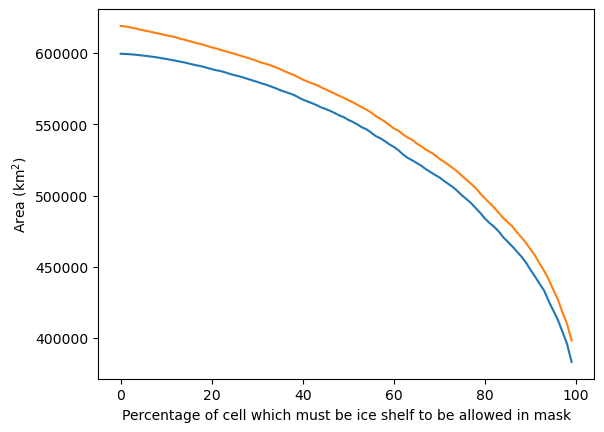

In [48]:
fig, ax = plt.subplots(1,1)
ax.plot(thresholds, areas, label = 'Bmach2')
ax.plot(thresholds, areas2, label = 'Bmach3')
ax.set_xlabel('Percentage of cell which must be ice shelf to be allowed in mask')
ax.set_ylabel('Area (km$^2$)')

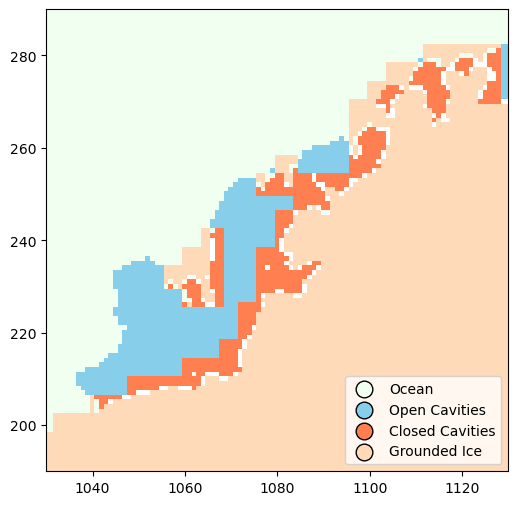

In [15]:
fig, ax = plt.subplots(1,1, figsize = (6,6))
from matplotlib.colors import ListedColormap
im = plt.imshow(ocean_only_nan, cmap = ListedColormap(["honeydew"]), origin = 'lower')
plt.scatter(-0,-0, color = 'honeydew', label = 'Ocean')
im = plt.imshow(open_cavities_nan, cmap = ListedColormap(["skyblue"]), origin = 'lower')
plt.scatter(-0,-0, color = 'skyblue', label = 'Open Cavities')
im = plt.imshow(closed_cavities_nan, cmap = ListedColormap(["coral"]), origin = 'lower')
plt.scatter(-0,-0, color = 'coral', label = 'Closed Cavities')
im = plt.imshow(grounded_ice_nan, cmap = ListedColormap(["peachpuff"]), origin = 'lower')
plt.scatter(-0,-0, color = 'peachpuff', label = 'Grounded Ice')
im.set_clim(0.8,2)
leg = ax.legend(loc = 4, markerscale = 2, fontsize = 10)
for h in leg.legend_handles:
    h.set_edgecolor("black")
    h.set_linewidth(1.0)
    
#ax.axis('off')
ax.set_xlim(1030,1130);
ax.set_ylim(190,290);
#ax.set_xlim(450,550);
#ax.set_ylim(0,100);

In [16]:
# Save one file for the 
ds = xr.Dataset(
        data_vars=dict(
            ocean_only              = (["y", "x"], ocean_only.data),
            ocean_only_nan          = (["y", "x"], ocean_only_nan.data),
            all_cavities            = (["y", "x"], all_cavities.data),
            all_cavities_nan        = (["y", "x"], all_cavities_nan.data),
            closed_cavities         = (["y", "x"], closed_cavities.data),
            closed_cavities_nan     = (["y", "x"], closed_cavities_nan.data),
            open_cavities           = (["y", "x"], open_cavities.data),
            open_cavities_nan       = (["y", "x"], open_cavities_nan.data),
            ocean_open_cavities     = (["y", "x"], open_cav_ocean.data),
            ocean_open_cavities_nan = (["y", "x"], open_cav_ocean.data),
            grounded_ice            = (["y", "x"], grounded_ice.data),
            grounded_ice_nan        = (["y", "x"], grounded_ice_nan.data),    
            basins_NEMO             = (["y", "x"], basins_remapped),
            ),
        coords=dict(
            lon=(("y", "x"), bounds25.lon.values),
            lat=(("y", "x"), bounds25.lat.values),    ),
        attrs=dict(description="Masks for grounded ice, floating ice and open ocean from Bedmachine Antarctica v3", 
                  ),
    )
ds.to_netcdf(filepath_new_mask)
print('You have saved the following file')
print(filepath_new_mask)

You have saved the following file
/bettik/ockendeh/NEMO_simulations/test_mask_geoms/geometric_masks_NEMO025_BMach3_60pc.nc


## To accompany this mask we also need:
**Bathymetry, ice shelf draft (and slopes), distance to GL, distance to OO, distance to OC, fraction of melt to keep**

In [17]:
do_calculation = True
if do_calculation == True:
    # Calculate the bathymetry and ice shelf draft within each cell 
    transformer = Transformer.from_crs("epsg:4326","epsg:3031",always_xy=True)
    # Create empty arrays 
    mean_bedelev = np.ones(bounds25.lat.shape) * np.nan
    mean_draft = np.ones(bounds25.lat.shape) * np.nan
    #for i in tqdm(range(200,210)):
    #    for j in range(200,210):
    for i in tqdm(range(bounds25.lat.shape[0])):
        for j in range(bounds25.lon.shape[1]):
            pass 
            # Only calculate masks for region we actually need it 
            if closed_cavities_nan[i,j] == 1:
                x_square = []
                y_square = []
                for jkl in (0,1,2,3):
                    lat_jkl = bounds25.lat_bnds.sel(nv4 = jkl)[i,j].values
                    lon_jkl = bounds25.lon_bnds.sel(nv4 = jkl)[i,j].values
                    x2, y2 = transformer.transform(lon_jkl, lat_jkl)
                    x_square.append(x2)
                    y_square.append(y2)
                bounds = [np.nanmin(x_square), np.nanmax(x_square), np.nanmin(y_square), np.nanmax(y_square)]
                # Extract the bedmachine mask within the boundaries of the cell 
                bmach_slice = bmach3.sel(x=slice(bounds[0], bounds[1]), y=slice(bounds[3], bounds[2]))
                if len(bmach_slice.x) == 0:
                    a = np.nan
                else:
                    X, Y = np.meshgrid(bmach_slice.x.values, bmach_slice.y.values)
                    # List corners of rotated rectangle and create polygon
                    corners = [(x_square[0], y_square[0]), (x_square[1], y_square[1]), \
                           (x_square[2], y_square[2]), (x_square[3], y_square[3])]
                    poly = Polygon(corners)# Mask of points inside polygon
                    mask = contains_xy(poly, X, Y)
                    # Extract bmach_slice inside polygon
                    sub_mask = bmach_slice.mask.where(mask == True)
                    # IF WE ARE IN THE ICE SHELF REGION
                    # Extract only values in ice shelf region
                    sub_mask1 = xr.where(sub_mask == 3, True, False)
                    sub_mask2 = xr.where(sub_mask > -1, True, False)
                    if np.sum(sub_mask1) > 0:
                        mask_bmach = bmach_slice.where(sub_mask1 == True)
                        #mean_bedelev[i,j] = mask_bmach.bed.mean()
                        #mean_draft[i,j] = (mask_bmach.surface - mask_bmach.thickness).mean()
                        mean_bedelev[i,j] = mask_bmach.bed.median()
                        mean_draft[i,j] = (mask_bmach.surface - mask_bmach.thickness).median()
                    else:
                        mask_bmach = bmach_slice.where(sub_mask2 == True)
                        #mean_bedelev[i,j] = mask_bmach.bed.mean()
                        #mean_draft[i,j] = (mask_bmach.surface - mask_bmach.thickness).mean() 
                        mean_bedelev[i,j] = mask_bmach.bed.median()
                        mean_draft[i,j] = (mask_bmach.surface - mask_bmach.thickness).median()
    if filepath_bedmachine == '../AIAI_data/BedmachineAntarctica-2020-07-15.nc':
        np.savetxt('bathy_BM2_Xpc_median.csv', mean_bedelev)
        np.savetxt('draft_BM2_Xpc_median.csv', mean_draft)
    elif filepath_bedmachine == '../AIAI_data/BedMachineAntarctica-v3.nc':
        np.savetxt('bathy_BM3_Xpc_median.csv', mean_bedelev)
        np.savetxt('draft_BM3_Xpc_median.csv', mean_draft)
    elif filepath_bedmachine == '../AIAI_data/BedMachineAntarctica-v4.0.nc':
        np.savetxt('bathy_BM4_Xpc_median.csv', mean_bedelev)
        np.savetxt('draft_BM4_Xpc_median.csv', mean_draft)
    else:
        print('No bedmachine provided?')
    else:
    # Load from file 
        if filepath_bedmachine == '../AIAI_data/BedmachineAntarctica-2020-07-15.nc':
            mean_bedelev = np.loadtxt('bathy_BM2_Xpc_median.csv')
            mean_draft   = np.loadtxt('draft_BM2_Xpc_median.csv')
        elif filepath_bedmachine == '../AIAI_data/BedMachineAntarctica-v3.nc':
            mean_bedelev = np.loadtxt('bathy_BM3_Xpc_median.csv')
            mean_draft   = np.loadtxt('draft_BM3_Xpc_median.csv')
        elif filepath_bedmachine == '../AIAI_data/BedMachineAntarctica-v4.0.nc':
            mean_bedelev = np.loadtxt('bathy_BM4_Xpc_median.csv')
            mean_draft   = np.loadtxt('draft_BM4_Xpc_median.csv')
        else:
            print('You haven\'t saved a file for this version of Bedmachine') 
    print('Bathymetry and Ice Shelf draft loaded from file')

100%|█████████████████████████████████████████| 439/439 [02:52<00:00,  2.55it/s]


In [18]:
plot_bathy = False
if plot_bathy == True:
    fig, ax = plt.subplots(1,1, figsize = (20,10))
    plt.pcolor(mean_bedelev)
    cbar = plt.colorbar(orientation = 'horizontal', shrink = 0.2, pad = -0.2)
    cbar.set_label('Bathymetry', fontweight = 'bold', fontsize = 20)
    ax.axis('off')
    #plt.clim(10,0)

In [19]:
# And for each point in the mask, the distance to the nearest grounded cell, nearest open ocean cell and nearest open cavity/ocean

In [20]:
# Create files of distances and slopes
# Create a pyproj transform to go from lat lon to polar stereo
transformer = Transformer.from_crs("epsg:4326","epsg:3031")

# Create a list of all the points in closed ice shelves 
CC_lat, CC_lon = bounds25.lat.data[closed_cavities == 1], bounds25.lon.data[closed_cavities == 1]
CC_x, CC_y = transformer.transform(CC_lat, CC_lon)
points_CC = np.array(list(zip(CC_x, CC_y)))
# Create a list of all the grounded ice points
GL_lat, GL_lon = bounds25.lat.data[grounded_ice == 1], bounds25.lon.data[grounded_ice == 1]
GL_x, GL_y = transformer.transform(GL_lat, GL_lon)
points_GL = np.array(list(zip(GL_x, GL_y)))
# Create a list of all the open ocean points 
OO_lat, OO_lon = bounds25.lat.data[ocean_only == 1], bounds25.lon.data[ocean_only == 1]
OO_x, OO_y = transformer.transform(OO_lat, OO_lon)
points_OO = np.array(list(zip(OO_x, OO_y)))
# Create a list of all the open ocean cavity points
OC_lat, OC_lon = bounds25.lat.data[open_cav_ocean == 1], bounds25.lon.data[open_cav_ocean == 1]
OC_x, OC_y = transformer.transform(OC_lat, OC_lon)
points_OC = np.array(list(zip(OC_x, OC_y)))

# Create the cKD Tree for the grounding line 
tree = cKDTree(points_GL)
# Query the cKD Tree for the closed cavity points 
dist, index = tree.query(points_CC, k = 1)
distances_GL = np.ones(bounds25.lat.data.shape)*np.nan
distances_GL[closed_cavities == 1] = dist

# Create the cKD Tree for the open ocean
tree = cKDTree(points_OO)
# Query the cKD Tree for the closed cavity points 
dist, index = tree.query(points_CC, k = 1)
distances_OO = np.ones(bounds25.lat.data.shape)*np.nan
distances_OO[closed_cavities == 1] = dist

# Create the cKD Tree for the open ocean and cavities
tree = cKDTree(points_OC)
# Query the cKD Tree for the closed cavity points 
dist, index = tree.query(points_CC, k = 1)
distances_OC = np.ones(bounds25.lat.data.shape)*np.nan
distances_OC[closed_cavities == 1] = dist

In [21]:
plot_dist_GL = False
if plot_dist_GL == True:
    fig, ax = plt.subplots(1,1, figsize = (20,10))
    im = plt.pcolor(distances_GL, cmap = 'plasma_r')
    im.set_clim(0,50000)
    cbar = plt.colorbar(orientation = 'horizontal', shrink = 0.2, pad = -0.2)
    cbar.set_label('Distance to\nGrounding Line', fontweight = 'bold', fontsize = 20)
    ax.axis('off')
    #plt.clim(10,0)

In [22]:
# In order to calculate the slopes we need the distance between points, 
# and because the points are on the NEMO lat-lon grid we need to convert them to polar stereo the calculate the distances 
# Create a pyproj transformer to transform onto polar stereo
lat, lon = bounds25.lat.data, bounds25.lon.data
grid_x, grid_y = transformer.transform(lat, lon)
# Use the np.roll function to move the data slightly 
shifted_x_p0 = (grid_x - np.roll(grid_x, shift = 1, axis = 0))
shifted_x_m0 = (grid_x - np.roll(grid_x, shift = -1, axis = 0))
shifted_x_p1 = (grid_x - np.roll(grid_x, shift = 1, axis = 1))
shifted_x_m1 = (grid_x - np.roll(grid_x, shift = -1, axis = 1))
shifted_y_p0 = (grid_y - np.roll(grid_y, shift = 1, axis = 0))
shifted_y_m0 = (grid_y - np.roll(grid_y, shift = -1, axis = 0))
shifted_y_p1 = (grid_y - np.roll(grid_y, shift = 1, axis = 1))
shifted_y_m1 = (grid_y - np.roll(grid_y, shift = -1, axis = 1))
# Because you need to calculate the hypotenuse distance you need x and y for both directions of shift 
shifted_p_lon = np.sqrt(shifted_x_p0**2 + shifted_y_p0**2) # lon
shifted_m_lon = np.sqrt(shifted_x_m0**2 + shifted_y_m0**2) # lon 
shifted_p_lat = np.sqrt(shifted_x_p1**2 + shifted_y_p1**2) # lat
shifted_m_lat = np.sqrt(shifted_x_m1**2 + shifted_y_m1**2) # lat

In [23]:
# Bathymetry and Ice Shelf darft are supposed to be positive 
if np.nanmean(mean_bedelev)<0:
    bathymetry = - mean_bedelev
else:
    bathymetry = mean_bedelev

if np.nanmean(mean_draft) <0:
    isf_draft = - mean_draft
else:
    isf_draft = mean_draft

In [24]:
interface = isf_draft*all_cavities_nan
interface_p_lon = ( + interface - np.roll(interface, shift = 1, axis = 0))/shifted_p_lon
interface_m_lon = (- interface + np.roll(interface, shift = -1, axis = 0))/shifted_m_lon
interface_p_lat = (+ interface - np.roll(interface, shift = 1, axis = 1))/shifted_p_lat
interface_m_lat = (- interface + np.roll(interface, shift = -1, axis = 1))/shifted_m_lat
bathymetry = bathymetry*all_cavities_nan
bathymetry_p_lon = ( + bathymetry - np.roll(bathymetry, shift = 1, axis = 0))/shifted_p_lon
bathymetry_m_lon = (- bathymetry + np.roll(bathymetry, shift = -1, axis = 0))/shifted_m_lon
bathymetry_p_lat = (+ bathymetry - np.roll(bathymetry, shift = 1, axis = 1))/shifted_p_lat
bathymetry_m_lat = (- bathymetry + np.roll(bathymetry, shift = -1, axis = 1))/shifted_m_lat
# Take the mean to get the actual local slope (and account for bendy points)
slope_isdraft_lon = np.nansum((interface_p_lon,interface_m_lon), axis = 0)/2
slope_isdraft_lat = np.nansum((interface_p_lat,interface_m_lat), axis = 0)/2
slope_bathy_lon = np.nansum((bathymetry_p_lon,bathymetry_m_lon), axis = 0)/2
slope_bathy_lat = np.nansum((bathymetry_p_lat,bathymetry_m_lat), axis = 0)/2
print('Local meridional and zonal slopes')

Local meridional and zonal slopes


In [25]:
print('If you have calculated the slopes properly, then there shouldn\'t be any nan values')
print('The following numbers should all be 0')
print(np.sum(np.isnan(slope_isdraft_lon)), np.sum(np.isnan(slope_isdraft_lat)), np.sum(np.isnan(slope_bathy_lon)), \
      np.sum(np.isnan(slope_bathy_lat)))

If you have calculated the slopes properly, then there shouldn't be any nan values
The following numbers should all be 0
0 0 0 0


In [26]:
basin_nos = np.unique(basins_remapped)

In [27]:
# To calculate the rotated slopes then we need to look at things on a basin by basin basisd
direction_to_front = np.ones(bounds25.lat.data.shape) * np.nan
no_cav_basins = []
#basin_no = 1
for jj in range(len(basin_nos)):
    basin_no = int(basin_nos[jj])
    mask_basin = xr.where((basins_remapped == basin_no), 1, np.nan)
    x_basin = CC_x[basins_remapped[closed_cavities_nan == 1] == basin_no]
    y_basin = CC_y[basins_remapped[closed_cavities_nan == 1] == basin_no]
    if len(x_basin) > 0:
        mean_x_basin = np.mean(x_basin)
        mean_y_basin = np.mean(y_basin)
        nearest_points_i = index[basins_remapped[closed_cavities_nan == 1] == basin_no]
        nearest_x_i = np.ones(len(np.unique(nearest_points_i)))
        nearest_y_i = np.ones(len(np.unique(nearest_points_i)))
        for i in range(len(np.unique(nearest_points_i))):
            nearest_x_i[i], nearest_y_i[i] = OC_x[np.unique(nearest_points_i)[i]], \
                                                   OC_y[np.unique(nearest_points_i)[i]]
        mean_x_i = np.mean(nearest_x_i)
        mean_y_i = np.mean(nearest_y_i)
        direction = np.arctan2(mean_x_basin - mean_x_i, mean_y_basin - mean_y_i)
    else:
        direction = np.nan
        no_cav_basins.append(basin_no)
    #print(jj,len(x_basin), len(nearest_points_i),direction)
    direction_to_front[mask_basin == 1] = np.ones(int(np.nansum(mask_basin))) * direction
print('No closed cavities in the following basins:')
print(no_cav_basins)

No closed cavities in the following basins:
[16, 17, 21, 22, 24, 27, 28, 30, 31, 33, 34, 35, 37, 38, 40, 43, 45, 52, 67, 69, 79, 80, 82, 86, 90, 107, 115, 118, 124, 125, 126]


In [28]:
# Then rotate the calculated slopes to have the slope towards the ice front and the slope across the ice front 
slope_isdraft_hypot = np.sqrt(slope_isdraft_lon **2 + slope_isdraft_lat **2)
angle_isdraft = np.arctan2(slope_isdraft_lon,slope_isdraft_lat)- direction_to_front
slope_is_across_front = slope_isdraft_hypot * np.sin(angle_isdraft)
slope_is_towards_front = slope_isdraft_hypot * np.cos(angle_isdraft)
slope_bathy_hypot = np.sqrt(slope_bathy_lon **2 + slope_bathy_lat **2)
angle_bathy = np.arctan2(slope_bathy_lon,slope_bathy_lat)- direction_to_front
slope_ba_across_front = slope_bathy_hypot * np.sin(angle_bathy)
slope_ba_towards_front = slope_bathy_hypot * np.cos(angle_bathy)
print('Rotated slopes')

Rotated slopes


In [29]:
print('If you have calculated the slopes properly, then there shouldn\'t be any nan values')
print('The following numbers should all be 0')
print(np.sum(np.isnan(slope_is_across_front[closed_cavities == 1])), np.sum(np.isnan(slope_is_towards_front[closed_cavities == 1])), 
      np.sum(np.isnan(slope_ba_across_front[closed_cavities == 1])), np.sum(np.isnan(slope_ba_towards_front[closed_cavities == 1])))

If you have calculated the slopes properly, then there shouldn't be any nan values
The following numbers should all be 0
0 0 0 0


In [30]:
np.nanmean(bathymetry)

np.float64(711.9471413953627)

In [31]:
# And then save these to file 
# Note that bathymetry and isf_draft need to be positive (hopefully this doesn't cause confusion later) 
ds = xr.Dataset(
            data_vars=dict(
                areas                  = (["y", "x"], geoms.areas.data),
                fraction               = (["y", "x"], fraction.data),
                bathymetry             = (["y", "x"], bathymetry),
                isf_draft              = (["y", "x"], isf_draft),
                distances_GL           = (["y", "x"], distances_GL.data),
                distances_OO           = (["y", "x"], distances_OO.data),
                distances_OC           = (["y", "x"], distances_OC.data),
                slope_isdraft_lon      = (["y", "x"], slope_isdraft_lon.data),
                slope_isdraft_lat      = (["y", "x"], slope_isdraft_lat.data),
                slope_bathy_lon        = (["y", "x"], slope_bathy_lon.data),
                slope_bathy_lat        = (["y", "x"], slope_bathy_lat.data),
                slope_is_across_front  = (["y", "x"], slope_is_across_front.data),
                slope_is_towards_front = (["y", "x"], slope_is_towards_front.data),
                slope_ba_across_front  = (["y", "x"], slope_ba_across_front.data),
                slope_ba_towards_front = (["y", "x"], slope_ba_towards_front.data),
                ),
            coords=dict(
                lon=(("y", "x"), bounds25.lon.data),
                lat=(("y", "x"), bounds25.lat.data),    ),
            attrs=dict(description = "Required geometry variables for the BMv3 geometry", 
                       ),
                )
ds.to_netcdf(filepath_geomvars_new)
print('You have saved the following file')
print(filepath_geomvars_new)


You have saved the following file
/bettik/ockendeh/NEMO_simulations/test_mask_geoms/geom_vars_NEMO025_BMach3_60pc.nc
